In [130]:
from casacore.tables import table as tbl
import numpy as np
import matplotlib.pyplot as plt
import pyuvdata
import sys
sys.path.append("/opt/devel/rbyrne/rlb_LWA/LWA_data_preprocessing")
import LWA_calibrate
import importlib
from scipy.interpolate import interp1d
importlib.reload(LWA_calibrate)
importlib.reload(pyuvdata)

<module 'pyuvdata' from '/opt/devel/rbyrne/envs/py311/lib/python3.11/site-packages/pyuvdata/__init__.py'>

Applied calibration in CASA with `clearcal("/fast/rbyrne/20260407_123010-123201_83MHz.ms")` and then `applycal("/fast/rbyrne/20260407_123010-123201_83MHz.ms", gaintable="/fast/rbyrne/calibration_2026-04-07_10h_spwcorrected.B.flagged", applymode="calflagstrict", interp="nearest,nearest", flagbackup=False)`.

Here the data file is concatenated to contain 12 time steps and to use frequencies centered on 83 MHz where the equalization coefficient is held constant. The caltable is modified to collapse spws using the script flatten_caltable_spws.py. I also tested caltables that selected only frequencies present in the data file and with spws collapsed with Gregg's script (flatten_caltable_spws_Gregg.py). The results from all three caltables agree. Finally, I tested the original caltable with multiple spws and found that it does not agree.

In [131]:
calfile_name = "/fast/rbyrne/calibration_2026-04-07_10h_spwcorrected.B.flagged"

In [132]:
uv_calibrated = pyuvdata.UVData()
uv_calibrated.read("/fast/rbyrne/20260407_123010-123201_83MHz.ms", data_column="CORRECTED_DATA")
uv_uncal = pyuvdata.UVData()
uv_uncal.read("/fast/rbyrne/20260407_123010-123201_83MHz.ms", data_column="DATA")

Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 1.0, largest imaginary/real ratio was 9.283894542022608e-08.


### Check calibration of autocorrelations
Note that this does not verify that the phase of the applied gains is correct

In [133]:
# Extract one autocorrelation spectrum
uv_uncal_autos = uv_uncal.select(inplace=False, antenna_names=["LWA018"])
uv_calibrated_autos = uv_calibrated.select(inplace=False, antenna_names=["LWA018"])
uv_uncal_autos.select(ant_str="auto")
uv_calibrated_autos.select(ant_str="auto")

In [134]:
gain_amps = np.sqrt(uv_uncal_autos.data_array / uv_calibrated_autos.data_array)
gain_amps[np.where(uv_uncal_autos.flag_array)] = np.nan
gain_amps[np.where(uv_calibrated_autos.flag_array)] = np.nan

In [135]:
# Confirm that the inferred gain amplitudes match between all time steps
for time_ind in range(12):
    print(np.nanmax(np.abs(gain_amps[time_ind,:,0] - gain_amps[0,:,0])))

0.0
4.656613e-10
4.656613e-10
4.656613e-10
4.656613e-10
2.3283064e-10
4.656613e-10
2.3283064e-10
4.656613e-10
2.3283064e-10
4.656613e-10
4.656613e-10


In [136]:
# Read calfile
cal = pyuvdata.UVCal()
cal.read(calfile_name)

In [137]:
cal_single_ant = cal.select(antenna_names=["LWA018"], inplace=False)
#cal_single_ant.gain_array[np.where(cal_single_ant.flag_array)] = np.nan
#cal_single_ant.gain_array[np.where(cal_single_ant.gain_array == 0)] = np.nan

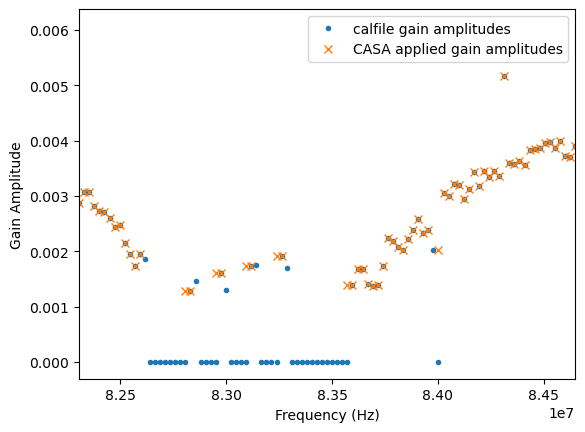

In [138]:
plt.plot(cal_single_ant.freq_array, np.abs(cal_single_ant.gain_array[0,:,0,0]), ".", label="calfile gain amplitudes")
plt.plot(uv_uncal_autos.freq_array, np.abs(gain_amps[0,:,0]), "x", label="CASA applied gain amplitudes")
plt.xlim([np.min(uv_uncal_autos.freq_array), np.max(uv_uncal_autos.freq_array)])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain Amplitude")
plt.legend()
plt.show()

In [139]:
# Calibrate with pyuvdata
uv_pyuvdata_cal = pyuvdata.utils.uvcalibrate(uv_uncal, cal, inplace=False, time_check=False)

gain_scale is not set, so there is no way to know what the resulting units are. For now, we assume that `gain_scale` matches whatever is on the UVData object (i.e. we do not change its units). Furthermore, all corrections concerning the pol_convention will be ignored.
pol_convention is not specified on the UVCal object, and uvc_pol_convention was not specified. Tentatively assuming that the UVCal and UVData objects (implicitly) have the same convention.
Neither uvd_pol_convention nor uvc_pol_convention are specified, so the resulting UVData object will have ambiguous convention. 
Times do not match between UVData and UVCal but time_check is False, so calibration will be applied anyway.


In [140]:
uv_pyuvdata_cal_autos = uv_pyuvdata_cal.select(inplace=False, antenna_names=["LWA018"])

In [141]:
gain_amps_pyuvdata = np.sqrt(uv_uncal_autos.data_array / uv_pyuvdata_cal_autos.data_array)
gain_amps_pyuvdata[np.where(uv_uncal_autos.flag_array)] = np.nan
gain_amps_pyuvdata[np.where(uv_pyuvdata_cal_autos.flag_array)] = np.nan

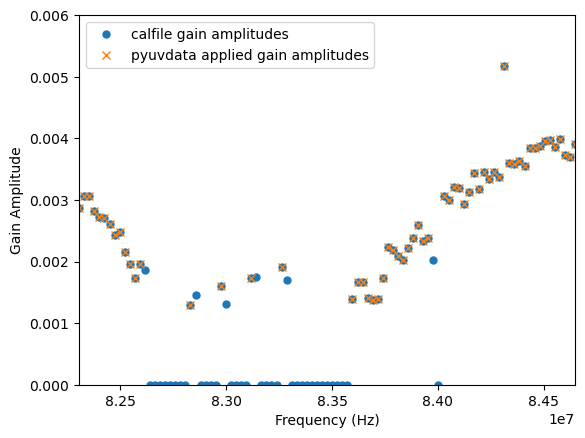

In [142]:
plt.plot(cal_single_ant.freq_array, np.abs(cal_single_ant.gain_array[0,:,0,0]), ".", markersize=10, label="calfile gain amplitudes")
plt.plot(uv_uncal_autos.freq_array, np.abs(gain_amps_pyuvdata[0,:,0]), "x", label="pyuvdata applied gain amplitudes")
#plt.plot(uv_uncal_autos.freq_array, np.abs(gain_amps[0,:,0]), "x", label="CASA applied gain amplitudes")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain Amplitude")
plt.xlim([np.min(uv_uncal_autos.freq_array), np.max(uv_uncal_autos.freq_array)])
plt.ylim([0,.006])
plt.legend()
plt.show()

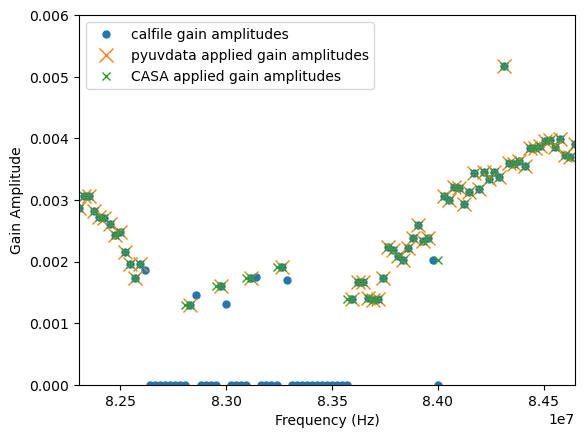

In [143]:
plt.plot(cal_single_ant.freq_array, np.abs(cal_single_ant.gain_array[0,:,0,0]), ".", markersize=10, label="calfile gain amplitudes")
plt.plot(uv_uncal_autos.freq_array, np.abs(gain_amps_pyuvdata[0,:,0]), "x", markersize=10, label="pyuvdata applied gain amplitudes")
plt.plot(uv_uncal_autos.freq_array, np.abs(gain_amps[0,:,0]), "x", label="CASA applied gain amplitudes")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain Amplitude")
plt.xlim([np.min(uv_uncal_autos.freq_array), np.max(uv_uncal_autos.freq_array)])
plt.ylim([0,.006])
plt.legend()
plt.show()

In [144]:
cal_single_ant.freq_array

array([13398437.5    , 13422363.28125, 13446289.0625 , ...,
       86826660.15625, 86850585.9375 , 86874511.71875], shape=(3072,))

In [145]:
uv_uncal_autos.freq_array

array([82304687.5    , 82328613.28125, 82352539.0625 , 82376464.84375,
       82400390.625  , 82424316.40625, 82448242.1875 , 82472167.96875,
       82496093.75   , 82520019.53125, 82543945.3125 , 82567871.09375,
       82591796.875  , 82615722.65625, 82639648.4375 , 82663574.21875,
       82687500.     , 82711425.78125, 82735351.5625 , 82759277.34375,
       82783203.125  , 82807128.90625, 82831054.6875 , 82854980.46875,
       82878906.25   , 82902832.03125, 82926757.8125 , 82950683.59375,
       82974609.375  , 82998535.15625, 83022460.9375 , 83046386.71875,
       83070312.5    , 83094238.28125, 83118164.0625 , 83142089.84375,
       83166015.625  , 83189941.40625, 83213867.1875 , 83237792.96875,
       83261718.75   , 83285644.53125, 83309570.3125 , 83333496.09375,
       83357421.875  , 83381347.65625, 83405273.4375 , 83429199.21875,
       83453125.     , 83477050.78125, 83500976.5625 , 83524902.34375,
       83548828.125  , 83572753.90625, 83596679.6875 , 83620605.46875,
      

### Check calibration of cross-correlations

In [146]:
uv_pyuvdata_single_bl = uv_pyuvdata_cal.select(antenna_names=["LWA273", "LWA311"], inplace=False)
uv_calibrated_single_bl = uv_calibrated.select(antenna_names=["LWA273", "LWA311"], inplace=False)
uv_pyuvdata_single_bl.select(ant_str="cross")
uv_calibrated_single_bl.select(ant_str="cross")
uv_pyuvdata_single_bl.data_array[np.where(uv_pyuvdata_single_bl.flag_array)] = np.nan + 1j*np.nan
uv_calibrated_single_bl.data_array[np.where(uv_calibrated_single_bl.flag_array)] = np.nan + 1j*np.nan

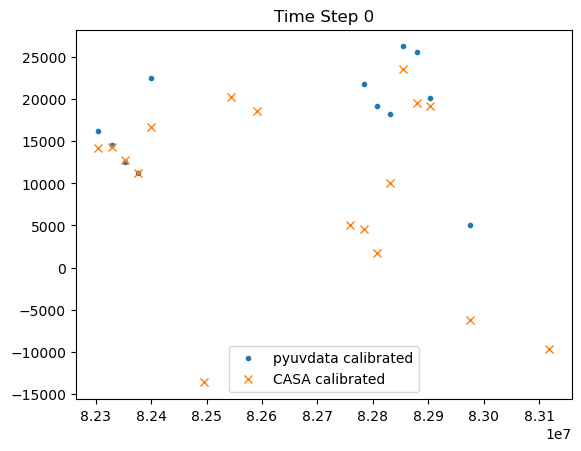

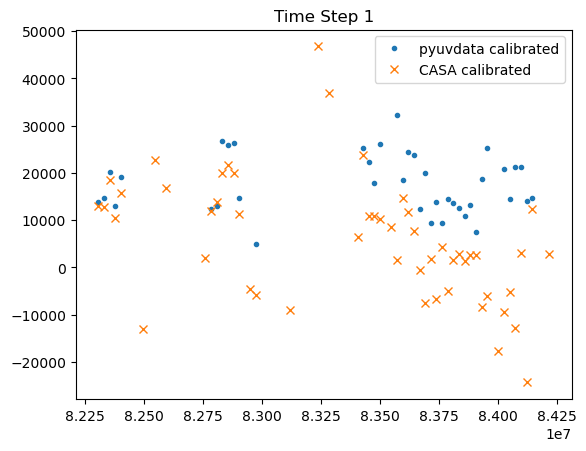

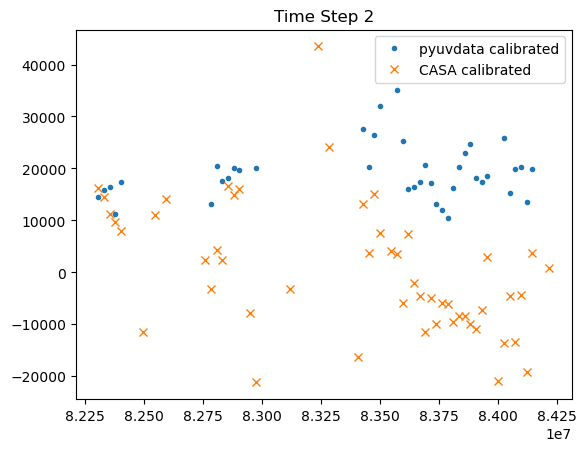

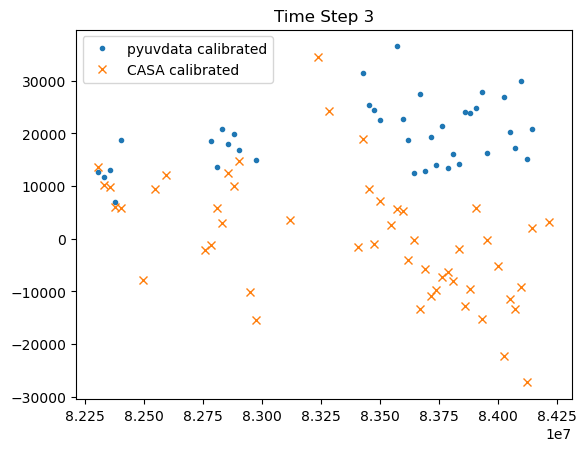

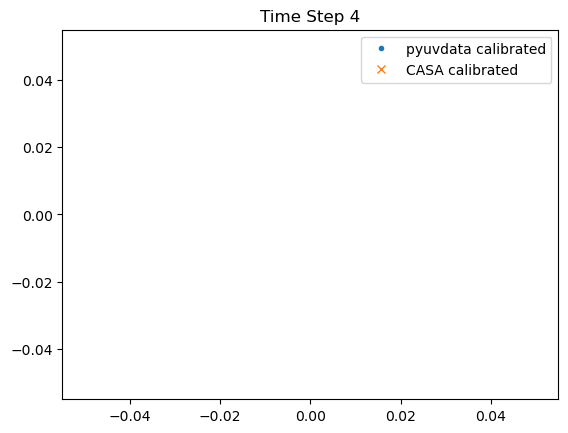

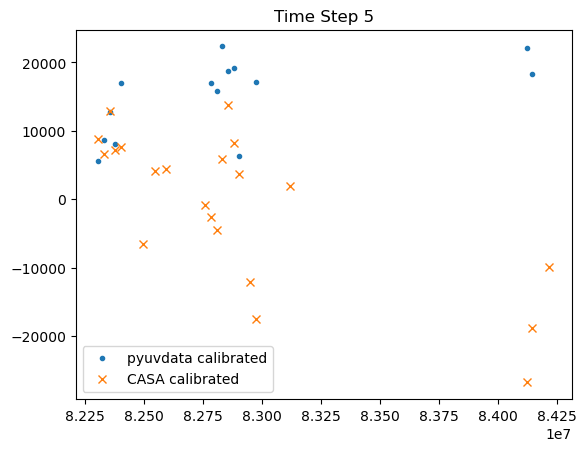

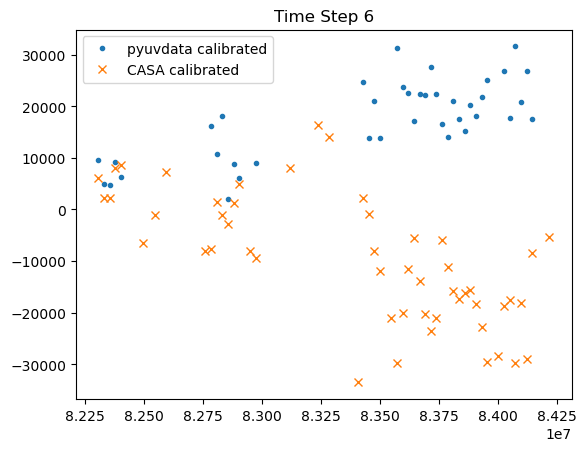

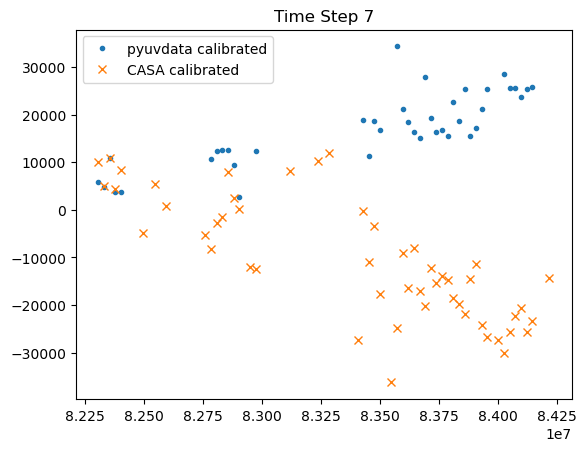

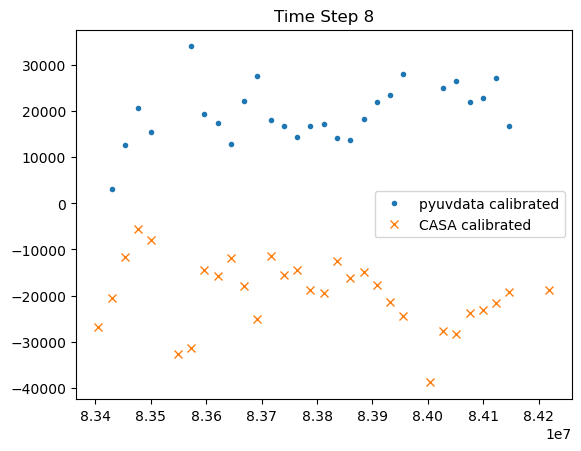

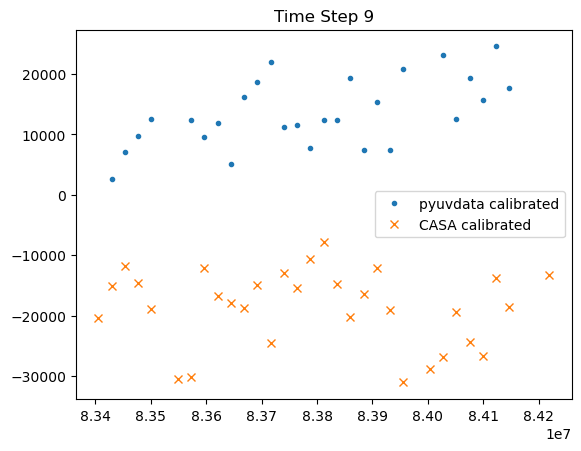

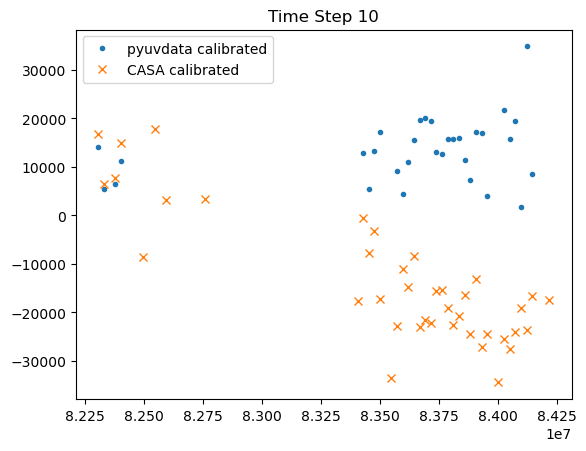

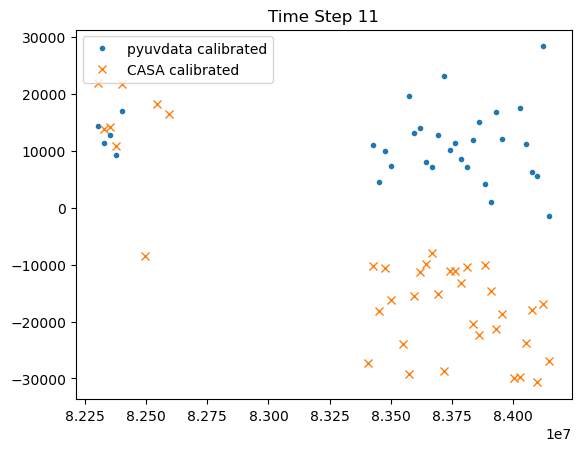

In [147]:
for time_ind in range(12):
    plt.plot(uv_pyuvdata_single_bl.freq_array, np.real(uv_pyuvdata_single_bl.data_array[time_ind,:,1]), ".", label="pyuvdata calibrated")
    plt.plot(uv_calibrated_single_bl.freq_array, np.real(uv_calibrated_single_bl.data_array[time_ind,:,1]), "x", label="CASA calibrated")
    plt.title(f"Time Step {time_ind}")
    plt.legend()
    plt.show()

In [148]:
np.shape(uv_pyuvdata_cal.flag_array)

(745536, 99, 4)

In [149]:
np.shape(uv_calibrated.flag_array)

(745536, 99, 4)

In [150]:
flag_array = np.max(np.concatenate([uv_pyuvdata_cal.flag_array[np.newaxis,:,:,:], uv_calibrated.flag_array[np.newaxis,:,:,:]]), axis=0)
uv_pyuvdata_cal.flag_array = flag_array
uv_calibrated.flag_array = flag_array
diff = uv_pyuvdata_cal.sum_vis(uv_calibrated, inplace=False, difference=True)
diff.data_array[np.where(diff.flag_array)] = np.nan + 1j*np.nan

Keyword DATA_COL in _extra_keywords is different in the two objects. Taking the first object's entry.


In [151]:
print(np.nanmax(np.abs(diff.data_array)))

937674.75


In [152]:
# Get fractional error:
summed = uv_pyuvdata_cal.sum_vis(uv_calibrated, inplace=False, difference=False)
print(np.nanmax(np.abs(diff.data_array)/np.abs(summed.data_array/2)))

Keyword DATA_COL in _extra_keywords is different in the two objects. Taking the first object's entry.


7898181.0


### Repeat analysis with conjugated visibilities

In [153]:
# Calibrate with pyuvdata, now with conjugated visibilities
uv_pyuvdata_cal = pyuvdata.utils.uvcalibrate(uv_uncal, cal, inplace=False, time_check=False, flip_gain_conj=True)

gain_scale is not set, so there is no way to know what the resulting units are. For now, we assume that `gain_scale` matches whatever is on the UVData object (i.e. we do not change its units). Furthermore, all corrections concerning the pol_convention will be ignored.
pol_convention is not specified on the UVCal object, and uvc_pol_convention was not specified. Tentatively assuming that the UVCal and UVData objects (implicitly) have the same convention.
Neither uvd_pol_convention nor uvc_pol_convention are specified, so the resulting UVData object will have ambiguous convention. 
Times do not match between UVData and UVCal but time_check is False, so calibration will be applied anyway.


In [154]:
uv_pyuvdata_single_bl = uv_pyuvdata_cal.select(antenna_names=["LWA273", "LWA311"], inplace=False)
uv_calibrated_single_bl = uv_calibrated.select(antenna_names=["LWA273", "LWA311"], inplace=False)
uv_pyuvdata_single_bl.select(ant_str="cross")
uv_calibrated_single_bl.select(ant_str="cross")
uv_pyuvdata_single_bl.data_array[np.where(uv_pyuvdata_single_bl.flag_array)] = np.nan + 1j*np.nan
uv_calibrated_single_bl.data_array[np.where(uv_calibrated_single_bl.flag_array)] = np.nan + 1j*np.nan

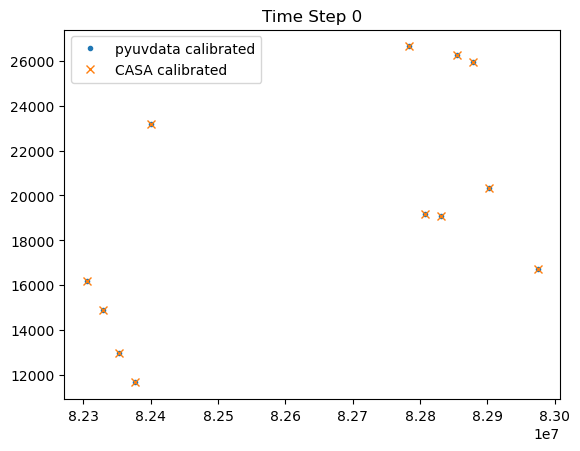

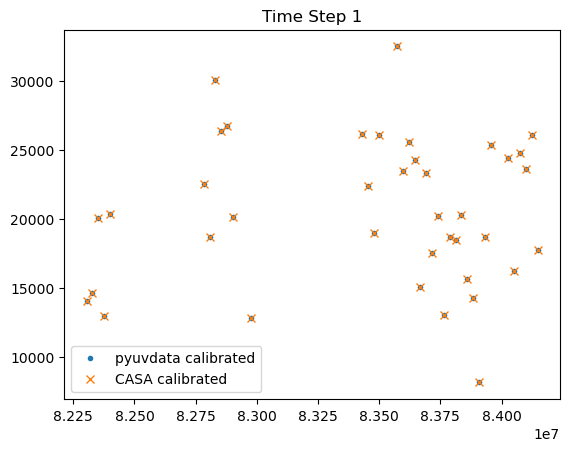

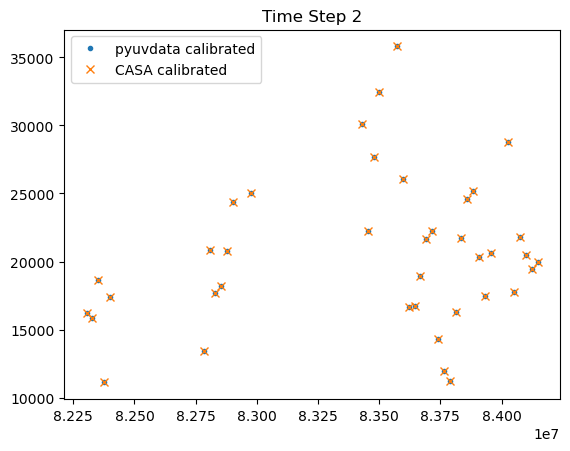

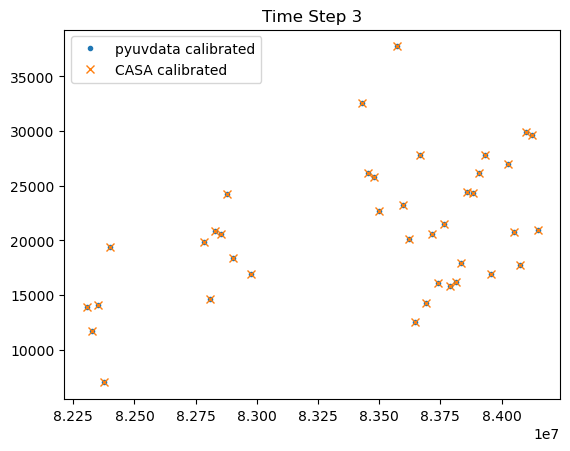

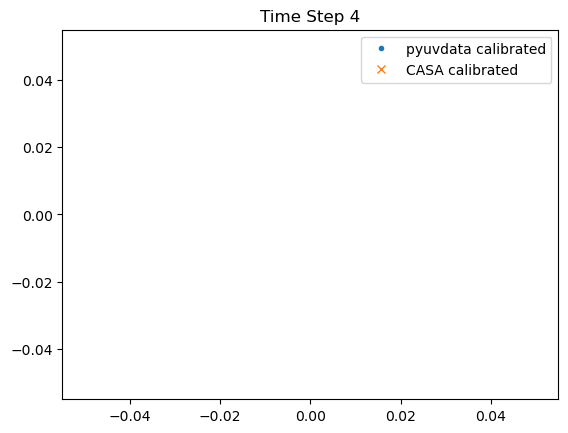

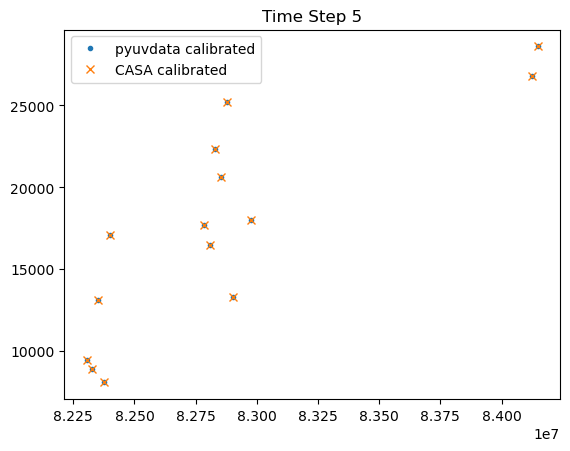

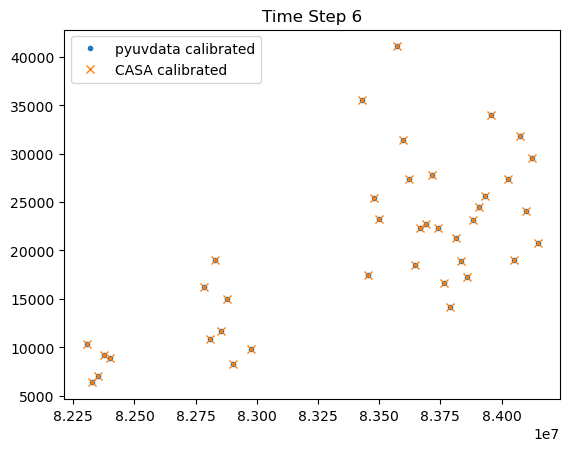

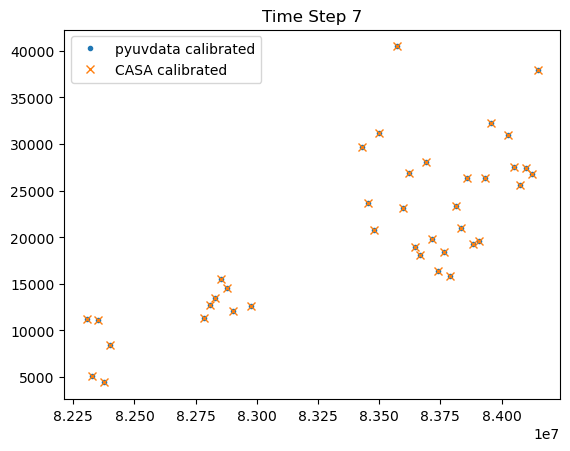

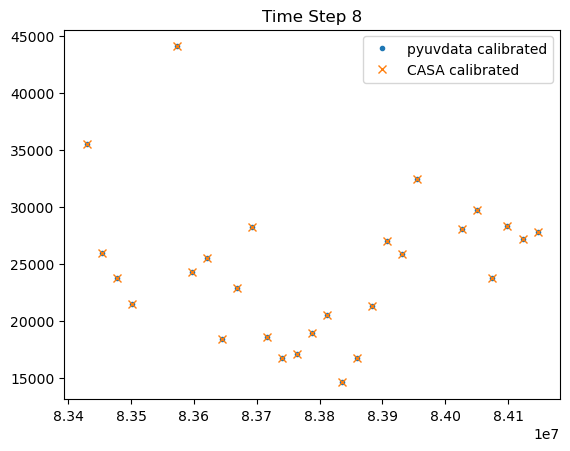

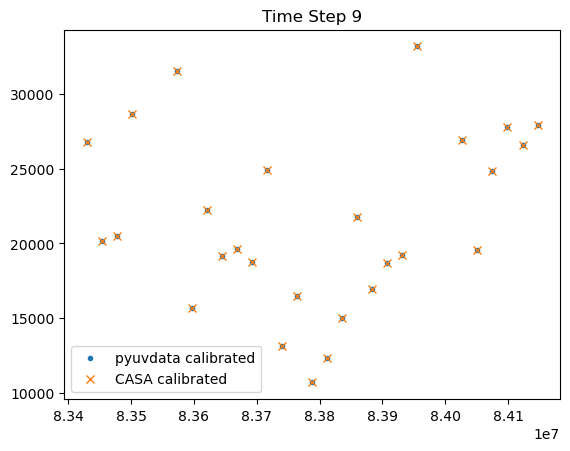

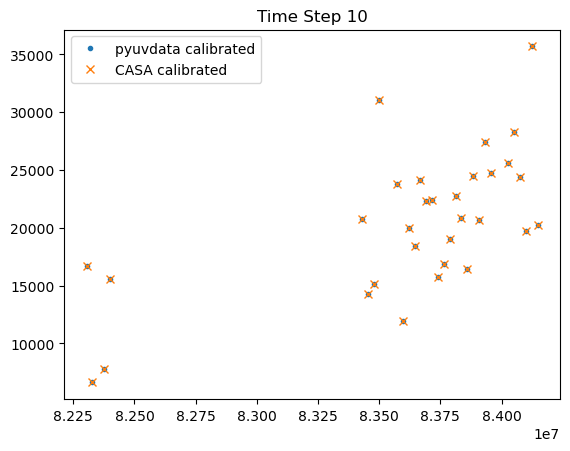

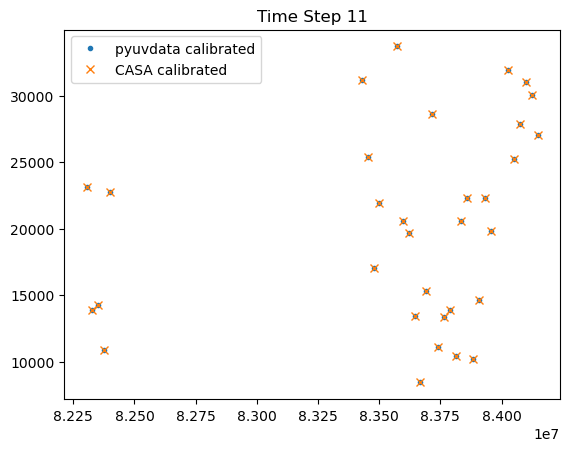

In [155]:
for time_ind in range(12):
    plt.plot(uv_pyuvdata_single_bl.freq_array, np.abs(uv_pyuvdata_single_bl.data_array[time_ind,:,1]), ".", label="pyuvdata calibrated")
    plt.plot(uv_calibrated_single_bl.freq_array, np.abs(uv_calibrated_single_bl.data_array[time_ind,:,1]), "x", label="CASA calibrated")
    plt.title(f"Time Step {time_ind}")
    plt.legend()
    plt.show()

In [156]:
diff = uv_pyuvdata_cal.sum_vis(uv_calibrated, inplace=False, difference=True)
diff.data_array[np.where(diff.flag_array)] = np.nan + 1j*np.nan

Keyword DATA_COL in _extra_keywords is different in the two objects. Taking the first object's entry.


In [157]:
print(np.nanmax(np.abs(diff.data_array)))

36.5377


In [158]:
# Get fractional error:
summed = uv_pyuvdata_cal.sum_vis(uv_calibrated, inplace=False, difference=False)
print(np.nanmax(np.abs(diff.data_array)/np.abs(summed.data_array/2)))

Keyword DATA_COL in _extra_keywords is different in the two objects. Taking the first object's entry.


0.00026753996
